# Information and noisy channels — Shannon entropy, mutual information, channel capacity and error correction

**Marcin Płodzień** — Institute of Theoretical Physics, Jagiellonian University in Kraków  
[ORCID 0000-0002-0835-1644](https://orcid.org/0000-0002-0835-1644) · [github.com/MarcinPlodzien](https://github.com/MarcinPlodzien) · [www](https://chaos.if.uj.edu.pl/marcinplodzien/)

*Quantum Many-Body Simulation — Chapter 14 — Quantum communication and cryptography*

## 1. Introduction and motivation

Every act of communication has the same structure. A sender, Alice, wants a receiver, Bob, to learn a message, and
the only connection between them is a physical channel: a copper wire, an optical fibre, a radio link, a letter in the
post. Real channels are noisy. A bit sent as $1$ sometimes arrives as $0$ because of thermal noise in an amplifier, a
scratch on a disc or a photon lost in a fibre. Two questions follow. How much does a message actually contain, so that
no channel use is wasted on redundant symbols? And how can Alice and Bob communicate reliably when the channel
corrupts a fixed fraction of the bits? In 1948 Claude Shannon answered both questions with a single quantity, the
**entropy**, and founded information theory. His answers set the limits that every modem, mobile phone and hard disk
works against today.

Later in this chapter a third question joins the first two: how can Alice and Bob communicate *secretly*, when an
eavesdropper, Eve, may listen to the channel? The answer will need a shared secret key, and quantum mechanics will
offer a way to create one. The language of that answer is Shannon's. The error rate on a quantum key, the amount of
public discussion needed to correct it and the information that Eve may hold are all measured in the bits of this
notebook, and the same function $h(q)$ that sets the capacity of a noisy channel reappears in the rate of quantum key
distribution.

![Communication over a noisy channel: source, encoder, binary symmetric channel, decoder and receiver, with the information quantities of this notebook](figures/noisy_channel.svg)

**Figure 1.** Communication over a noisy channel. The source produces a message $m$ whose information content per
symbol is the entropy $H(X)$ (Section 3). The encoder turns $k$ message bits into $n\geq k$ channel bits by adding
parity bits, at a rate $R=k/n$; the example is the Hamming code of Section 6.2, which turns the message $1011$ into the
codeword $0110011$. The channel flips each bit independently with probability $q$; per use it carries the
mutual information $I(X{:}Y)$ (Section 4), at most the capacity $C=1-h(q)$ (Section 5). The decoder uses the
parity bits to locate and undo the flipped bit (Section 6). Shannon's noisy-channel coding theorem says that the error probability can
be made as small as desired at every rate below $C$ and at no rate above it.

**The idea.** Shannon measured information by *surprise*: an unlikely outcome tells more than a likely one. The
average surprise of a random source, its entropy, is exactly the number of bits per symbol that a
compressor needs. A noisy channel is described by the probabilities with which inputs become outputs, and the mutual
information between input and output says how much of the input survives. Its maximum over all ways of using the
channel, the capacity, is the largest rate of reliable communication. Reaching it requires error-correcting codes,
which add carefully chosen redundancy: parity bits, sums modulo 2 of message bits, whose violations reveal where the
errors are.

### 1.1 Road map

* **Section 3** defines surprise and entropy, plots the binary entropy $h(q)$, and compresses a biased coin with
  Huffman codes on blocks, approaching $H$ bits per symbol.
* **Section 4** introduces joint and conditional entropy and the mutual information $I(X{:}Y)$ on worked examples.
* **Section 5** defines a classical channel by its transition matrix, works through the noiseless, binary symmetric,
  erasure and Z-channels, simulates them, computes their capacities by scanning the input distribution, and states the
  noisy-channel coding theorem, tested with random codes.
* **Section 6** builds and simulates error correction: the repetition code, the Hamming(7,4) code with syndrome
  decoding, and the parity-check binary search that Alice and Bob use to correct a shared key by public discussion,
  with the number of revealed bits compared with $h(Q)$.
* **Section 7** connects reliable communication with secret communication, the next subject of this chapter.

### What you will learn

*Physics and information*

* entropy as average surprise and as the length of the best lossless compression;
* conditional entropy and mutual information as the bookkeeping of what one variable tells about another;
* a channel as a matrix of transition probabilities, and its capacity as the largest mutual information;
* the statement and the meaning of the noisy-channel coding theorem, and why codes with a fixed number of repetitions
  cannot reach it;
* error correction by public parity checks and its cost of about $h(Q)$ revealed bits per key bit.

*Numerical methods*

* plug-in estimates of entropies and mutual information from simulated counts, compared with closed forms;
* capacity by a one-dimensional scan over the input distribution;
* Monte Carlo estimates of error rates with binomial error bars.

*Implementation practice*

* a Huffman code built with a priority queue and checked by encoding and decoding a long string;
* syndrome decoding as a matrix product modulo 2;
* wrong controls that must fail: a Z-channel evaluated at the uniform input, a repetition code with an even number of
  copies, a parity check that cannot see two errors.

### Prerequisites

* [01 — JAX](../ch01_computational_toolbox/01_jax_from_scratch.ipynb): arrays and pseudo-random keys
  (`jax.random.PRNGKey`, `fold_in`).
* Basic probability: a probability distribution, the expectation value, independent events, the binomial distribution.

No quantum mechanics is needed in this notebook. Quantum states enter in the quantum part of this chapter, which
builds on the Bell states, teleportation and superdense coding of
[notebooks 19](../ch08_quantum_information_protocols/19_bell_states_and_chsh.ipynb),
[20](../ch08_quantum_information_protocols/20_quantum_teleportation.ipynb) and
[21](../ch08_quantum_information_protocols/21_entanglement_swapping_and_superdense_coding.ipynb).

## Configuration

Every notebook of this course starts with the same cell. Choose where to run (`DEVICE`) and the floating-point precision (`PRECISION`): `"double"` = `float64/complex128` (default, recommended for physics), `"single"` = `float32/complex64` (half the memory, faster on consumer GPUs, but watch the round-off). All code below derives its dtypes from `RDTYPE`/`CDTYPE` and its check tolerances from `TOL`, so nothing else needs to change.

In [1]:
# ==============================================================================
# CONFIGURATION  -- adapt to your hardware, then run the notebook top to bottom
# ==============================================================================
DEVICE    = "auto"     # "auto": use a GPU if JAX finds one, else CPU | "cpu" | "gpu"
PRECISION = "double"   # "double": float64/complex128 | "single": float32/complex64

import os
if DEVICE == "cpu":
    os.environ["JAX_PLATFORMS"] = "cpu"          # must be set BEFORE jax is imported

import os
import string
from functools import partial

import math
import numpy as np
import jax
import jax.numpy as jnp
from jax import lax

# Precision is configurable: "double" = float64/complex128 (default; needed for long time evolutions and
# tight validation), "single" = float32/complex64 (half the memory, faster on consumer GPUs).
# In a notebook PRECISION is defined in the Configuration cell; for this module use the env var QE_PRECISION.
PRECISION = globals().get("PRECISION", os.environ.get("QE_PRECISION", "double"))
jax.config.update("jax_enable_x64", PRECISION == "double")
RDTYPE = jnp.float64 if PRECISION == "double" else jnp.float32       # real dtype
CDTYPE = jnp.complex128 if PRECISION == "double" else jnp.complex64  # complex dtype of all states/operators
TOL = 1e-10 if PRECISION == "double" else 1e-4                       # tolerance for sanity checks (asserts)
_LETTERS = string.ascii_letters  # 52 einsum labels; a call needs (axes + new labels) <= 52: apply_gate on a state
                                 # N + k <= 52 (N <= 51 for k = 1), apply_gate_dm 2N + k <= 52 (N <= 25 for k = 1, 2),
                                 # apply_kraus_dm 2N + 2k + 1 <= 52 (N <= 24 for k = 1, N <= 23 for k = 2)

import time
import matplotlib.pyplot as plt

if DEVICE == "gpu" and jax.default_backend() == "cpu":
    print("WARNING: DEVICE='gpu' requested but JAX found no GPU -- running on CPU.")
print(f"JAX {jax.__version__} | backend: {jax.default_backend()} | devices: {jax.devices()}")
print(f"precision: {PRECISION} -> real {RDTYPE.__name__}, complex {CDTYPE.__name__}, check tolerance TOL={TOL:g}")


JAX 0.11.0 | backend: cpu | devices: [CpuDevice(id=0)]
precision: double -> real float64, complex complex128, check tolerance TOL=1e-10


## 2. Notebook helpers

Everything in this notebook is classical, so no quantum-engine function is needed. Random bits come from JAX's
counter-based generator: one master key per run, and an independent key for every experiment obtained with
`jax.random.fold_in(MASTER, i)`, so that the experiments do not share random numbers and every one is reproducible on
its own. The helper cell defines the binary entropy and the entropy of a distribution, used throughout.

In [2]:
# ==============================================================================
# PLOT STYLE + small helpers
# ==============================================================================
import heapq
import itertools
from math import comb

PALETTE = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#4a3aa7"]   # colour-blind-friendly, fixed order
MARKERS = ["o", "s", "^", "D", "v", "P"]
plt.rcParams.update({"axes.prop_cycle": plt.cycler(color=PALETTE), "axes.grid": True,
                     "grid.alpha": 0.3, "font.size": 10, "legend.frameon": False})

MASTER = jax.random.PRNGKey(50)          # one master key per run; experiment i uses fold_in(MASTER, i)


def key_for(i):
    """Independent key for experiment number i."""
    return jax.random.fold_in(MASTER, i)


def random_bits(key, n, p=0.5):
    """n independent bits, each equal to 1 with probability p (numpy uint8 array)."""
    return np.asarray(jax.random.bernoulli(key, p, (n,)), dtype=np.uint8)


def entropy(probs):
    """Shannon entropy in bits of a probability vector, Eq. (2); terms with p = 0 contribute 0 (p log p -> 0)."""
    p = np.asarray(probs, dtype=float).ravel()
    p = p[p > 0]
    return float(-(p * np.log2(p)).sum()) + 0.0           # + 0.0 turns -0.0 into 0.0


def h2(q):
    """Binary entropy h(q) = -q log2 q - (1-q) log2(1-q), Eq. (4); works on scalars and arrays, h(0) = h(1) = 0."""
    q = np.asarray(q, dtype=float)
    with np.errstate(divide="ignore", invalid="ignore"):
        out = -q * np.log2(np.where(q > 0, q, 1.0)) - (1 - q) * np.log2(np.where(q < 1, 1 - q, 1.0))
    return out if out.ndim else float(out)


def binom_se(p, n):
    """Standard error of an observed frequency p from n independent trials."""
    return float(np.sqrt(max(p * (1 - p), 1e-300) / n))

## 3. Information and entropy

### 3.1 Surprise

Suppose a random experiment has outcomes $x$ with probabilities $p(x)$. Learning that the outcome was $x$ is
informative in proportion to how unexpected it was: being told that the sun rose this morning carries almost no
information, being told the winning lottery number carries a lot. Shannon measured the information of a single
outcome by its **surprise**

$$s(x)=-\log_2p(x)=\log_2\frac1{p(x)}. \tag{1}$$

Three properties make this the natural choice. A certain outcome, $p=1$, has zero surprise. Rarer outcomes have larger
surprise. And for two independent experiments the probabilities multiply, $p(x,y)=p(x)p(y)$, so the surprises add,
$s(x,y)=s(x)+s(y)$, as an amount of information should. The base-2 logarithm sets the unit, the **bit**: the outcome
of a fair coin, $p=1/2$, carries $s=\log_22=1$ bit, and an outcome of probability $1/8$ carries $3$ bits, as much as
three fair coins together.

### 3.2 Shannon entropy

The **entropy** of a random variable $X$ is its average surprise,

$$H(X)=\sum_xp(x)\,s(x)=-\sum_xp(x)\log_2p(x), \tag{2}$$

with the convention $0\log_20=0$ (an outcome that never happens contributes nothing). It measures how uncertain we are
about $X$ before we look, in bits. If $X$ takes $M$ values, the entropy lies between two extremes,

$$0\leq H(X)\leq\log_2M, \tag{3}$$

with $H=0$ when one outcome is certain and $H=\log_2M$ exactly when all $M$ outcomes are equally likely. Three
examples: a fair coin has $H=1$ bit; a fair die has $H=\log_26\approx2.585$ bits; a coin that shows heads with
probability $0.9$ has $H=-0.9\log_20.9-0.1\log_20.1\approx0.469$ bits, less than half a bit, because its outcome is
usually predictable.

The next cell implements Eq. (2) (the helper `entropy`) and checks it on these examples, together with the bounds of
Eq. (3) on random distributions.

In [3]:
# ==============================================================================
# Eqs. (1)-(3): surprise and entropy on worked examples
# ==============================================================================
surprise = lambda p: -np.log2(p)                                   # Eq. (1)
assert surprise(0.5) == 1.0 and abs(surprise(1 / 8) - 3.0) < TOL
assert abs(surprise(0.5 * 0.25) - (surprise(0.5) + surprise(0.25))) < TOL   # independent events: surprises add

examples = {"fair coin": [0.5, 0.5], "biased coin (0.9, 0.1)": [0.9, 0.1], "fair die": [1 / 6] * 6,
            "loaded die (1/2, 1/10 x 5)": [0.5] + [0.1] * 5, "certain outcome": [1.0, 0.0]}
for name, p in examples.items():
    print(f"H({name:27s}) = {entropy(p):.4f} bits   (log2 M = {np.log2(len(p)):.4f})")
assert abs(entropy([0.5, 0.5]) - 1.0) < TOL
assert abs(entropy([1 / 6] * 6) - np.log2(6)) < TOL
assert abs(entropy([0.9, 0.1]) - 0.4689955935892812) < TOL
assert entropy([1.0, 0.0]) == 0.0

# Eq. (3) on random distributions: 0 <= H <= log2 M, with equality only for the uniform distribution
rng = np.random.default_rng(int(jax.random.randint(key_for(0), (), 0, 2**31 - 1)))
for M in (2, 3, 6, 16):
    P = rng.dirichlet(np.ones(M), size=1000)
    H = np.array([entropy(p) for p in P])
    assert H.min() >= 0 and H.max() < np.log2(M), M
    print(f"M = {M:2d}: 1000 random distributions, 0 <= H, max H = {H.max():.4f}, log2 M - max H = {np.log2(M) - H.max():.1e}")

H(fair coin                  ) = 1.0000 bits   (log2 M = 1.0000)
H(biased coin (0.9, 0.1)     ) = 0.4690 bits   (log2 M = 1.0000)
H(fair die                   ) = 2.5850 bits   (log2 M = 2.5850)
H(loaded die (1/2, 1/10 x 5) ) = 2.1610 bits   (log2 M = 2.5850)
H(certain outcome            ) = 0.0000 bits   (log2 M = 1.0000)


M =  2: 1000 random distributions, 0 <= H, max H = 1.0000, log2 M - max H = 2.6e-07
M =  3: 1000 random distributions, 0 <= H, max H = 1.5843, log2 M - max H = 7.1e-04
M =  6: 1000 random distributions, 0 <= H, max H = 2.5465, log2 M - max H = 3.8e-02
M = 16: 1000 random distributions, 0 <= H, max H = 3.8080, log2 M - max H = 1.9e-01


### 3.3 The binary entropy function

A bit that equals $1$ with probability $q$ and $0$ with probability $1-q$ has the entropy

$$h(q)=-q\log_2q-(1-q)\log_2(1-q), \tag{4}$$

the **binary entropy function**. It will appear in every notebook of this chapter, because an error that hits each bit
with probability $q$ is exactly such a biased bit. It rises from $h(0)=0$ to $h(1/2)=1$ and is symmetric,
$h(q)=h(1-q)$: a bit that is almost always wrong is as predictable as one that is almost always right. Its derivative,

$$h'(q)=\log_2\frac{1-q}{q}, \tag{5}$$

vanishes only at $q=1/2$ and diverges at the end points, so $h$ is steep near $0$: a small error rate already costs a
noticeable fraction of a bit. Four values recur in this chapter: $h(0.01)\approx0.081$, $h(0.05)\approx0.286$,
$h(0.11)\approx0.500$ and $h(1/4)\approx0.811$.

h(0.01) = 0.0808
h(0.05) = 0.2864
h(0.11) = 0.4999
h(0.25) = 0.8113


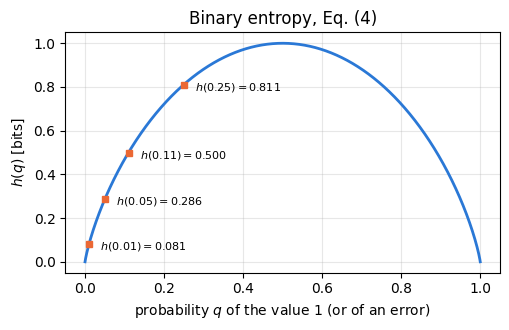

In [4]:
# ==============================================================================
# Eqs. (4)-(5): the binary entropy, its symmetry and its derivative
# ==============================================================================
qs = np.linspace(0, 1, 2001)
hq = h2(qs)
assert abs(h2(0.5) - 1) < TOL and h2(0.0) == 0 and h2(1.0) == 0
assert np.max(np.abs(hq - h2(1 - qs))) < TOL                         # symmetry h(q) = h(1-q)
for q in (0.01, 0.05, 0.11, 0.25):                                   # Eq. (4) = Eq. (2) for the distribution (q, 1-q)
    assert abs(h2(q) - entropy([q, 1 - q])) < TOL
    print(f"h({q:4.2f}) = {h2(q):.4f}")
eps = 1e-6
for q in (0.05, 0.3, 0.7):                                           # Eq. (5) against a central difference
    assert abs((h2(q + eps) - h2(q - eps)) / (2 * eps) - np.log2((1 - q) / q)) < 1e-6

fig, ax = plt.subplots(figsize=(5.2, 3.4))
ax.plot(qs, hq, color=PALETTE[0], lw=2)
for q in (0.01, 0.05, 0.11, 0.25):
    ax.plot(q, h2(q), MARKERS[1], color=PALETTE[1], ms=5)
    ax.annotate(f"$h({q})={h2(q):.3f}$", (q, h2(q)), xytext=(8, -4), textcoords="offset points", fontsize=8)
ax.set_xlabel("probability $q$ of the value 1 (or of an error)")
ax.set_ylabel("$h(q)$ [bits]")
ax.set_title("Binary entropy, Eq. (4)")
plt.tight_layout(); plt.show()

### 3.4 Entropy as the length of the best compression

The entropy has an operational meaning that goes beyond "average surprise": it is the smallest number of bits per
symbol into which a long message from the source can be compressed without loss. This is the content of Shannon's
fundamental theorem for a noiseless channel (Shannon 1948, Theorem 9), the source coding theorem. We state it in the
form we can test.

A **prefix code** assigns to every symbol (or block of symbols) a binary codeword such that no codeword is the
beginning of another; a string of concatenated codewords can then be cut back into codewords unambiguously, reading
from the left. For a known distribution, the **Huffman code** (Huffman 1952) has the smallest average length among all
prefix codes for the same symbols, or for the same blocks of symbols: repeatedly merge
the two least likely entries into one node of a binary tree, then read each codeword off the path from the root. If
we encode blocks of $k$ source symbols at a time, the average codeword length $\bar L_k$ per block satisfies

$$H(X)\leq\frac{\bar L_k}{k}<H(X)+\frac1k, \tag{6}$$

so the number of bits per source symbol approaches $H$ as the blocks grow, and no lossless code goes below $H$ on
average. For the biased coin with $p(1)=0.1$ a single-symbol code needs one full bit per symbol, while $H=0.469$.
Blocks of two tosses have the probabilities $0.81,0.09,0.09,0.01$; merging $0.01$ with one $0.09$, the result $0.10$
with the other $0.09$, and finally $0.19$ with $0.81$ gives codewords of lengths $1,2,3,3$, an average of
$0.81+2\cdot0.09+3\cdot0.10=1.29$ bits per block, or $0.645$ bits per toss.

A second view explains why $H$ is the right number. In a long string of $n$ symbols, almost every string that actually
occurs contains each symbol in about its expected proportion, and such a **typical** string has a probability close to
$2^{-nH}$,

$$-\frac1n\log_2p(x_1x_2\cdots x_n)\;\to\;H(X)\qquad(n\to\infty), \tag{7}$$

a statement that Shannon gave as his Theorem 3. It is the law of large numbers: for independent symbols
$-\log_2p(x_1\cdots x_n)=\sum_is(x_i)$ is a sum of $n$ independent surprises, whose mean tends to $H$. Since the typical strings carry nearly all the probability and each
has probability $\approx2^{-nH}$, there are about $2^{nH}$ of them, and numbering them takes $nH$ bits. For $n=1000$ tosses of the biased coin these are about
$2^{469}$ strings out of $2^{1000}$.

The next cell draws $201\,600$ tosses of the biased coin (a multiple of every block length used), checks Eq. (7) on
the sample, builds Huffman codes on blocks of $k=1,\dots,8$ tosses from the block probabilities, compresses the
actual string, decompresses it, and compares the number of bits per toss with $H$ and with the bounds of Eq. (6).

empirical frequency of 1: 0.1004 (+- 0.0007),  H = h(0.1) = 0.4690 bits
-log2 p(x_1..x_n) / n = 0.4703  (H = 0.4690, statistical spread 0.0021)

 k | mean codeword length / k  (Eq. 6) | measured bits per toss | H <= L/k < H + 1/k
 1 | 1.0000                             | 1.0000                 | ok


 2 | 0.6450                             | 0.6454                 | ok
 3 | 0.5327                             | 0.5335                 | ok
 4 | 0.4926                             | 0.4931                 | ok
 5 | 0.4802                             | 0.4814                 | ok
 6 | 0.4702                             | 0.4715                 | ok


 7 | 0.4743                             | 0.4759                 | ok
 8 | 0.4758                             | 0.4770                 | ok


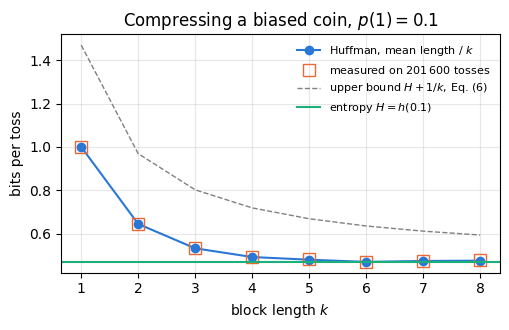

In [5]:
# ==============================================================================
# Eqs. (6)-(7): Huffman block codes on a biased coin, encoded and decoded
# ==============================================================================
def huffman_code(probs):
    """Huffman prefix code for symbols 0..M-1 with probabilities `probs`; returns a list of codeword strings.

    ALGORITHM   keep a priority queue of (probability, tie-breaker, {symbol: partial codeword}); merge the two least
                likely entries, prefixing '0' to the codewords of one and '1' to those of the other, until one is left.
    """
    heap = [(p, i, {i: ""}) for i, p in enumerate(probs)]
    heapq.heapify(heap)
    counter = len(heap)
    while len(heap) > 1:
        p0, _, c0 = heapq.heappop(heap)
        p1, _, c1 = heapq.heappop(heap)
        merged = {s: "0" + w for s, w in c0.items()} | {s: "1" + w for s, w in c1.items()}
        heapq.heappush(heap, (p0 + p1, counter, merged)); counter += 1
    code = heap[0][2]
    return [code[i] for i in range(len(probs))]


def block_probs(p1, k):
    """Probabilities of the 2^k blocks of k independent bits (block value b = sum_j bit_j 2^(k-1-j))."""
    ones = np.array([bin(b).count("1") for b in range(2**k)])
    return p1**ones * (1 - p1)**(k - ones)


def encode(bits, code, k):
    blocks = bits.reshape(-1, k) @ (2 ** np.arange(k - 1, -1, -1))
    return "".join(code[b] for b in blocks)


def decode(stream, code, k):
    inverse, out, word = {w: b for b, w in enumerate(code)}, [], ""
    for ch in stream:                                     # prefix property: the first match is the codeword
        word += ch
        if word in inverse:
            out.append(inverse[word]); word = ""
    assert word == "", "stream ended inside a codeword"
    blocks = np.array(out)
    return ((blocks[:, None] >> np.arange(k - 1, -1, -1)) & 1).astype(np.uint8).ravel()


P1, NTOSS = 0.1, 201_600                                  # 201600 = 240 x 840 is divisible by every k = 1..8
tosses = random_bits(key_for(1), NTOSS, P1)
H_coin = h2(P1)
p_hat = tosses.mean()
print(f"empirical frequency of 1: {p_hat:.4f} (+- {binom_se(P1, NTOSS):.4f}),  H = h(0.1) = {H_coin:.4f} bits")

# Eq. (7): the per-symbol surprise of the whole sample is close to H
n1 = int(tosses.sum())
per_symbol = -(n1 * np.log2(P1) + (NTOSS - n1) * np.log2(1 - P1)) / NTOSS
sd_surprise = np.sqrt(P1 * (1 - P1)) * abs(np.log2(P1 / (1 - P1))) / np.sqrt(NTOSS)   # std of the sample mean
print(f"-log2 p(x_1..x_n) / n = {per_symbol:.4f}  (H = {H_coin:.4f}, statistical spread {sd_surprise:.4f})")
assert abs(per_symbol - H_coin) < 5 * sd_surprise

print("\n k | mean codeword length / k  (Eq. 6) | measured bits per toss | H <= L/k < H + 1/k")
rows = []
for k in range(1, 9):
    pb = block_probs(P1, k)
    code = huffman_code(pb)
    lengths = np.array([len(w) for w in code])
    Lk = float(pb @ lengths) / k
    stream = encode(tosses, code, k)
    assert np.array_equal(decode(stream, code, k), tosses)          # lossless: the string comes back exactly
    measured = len(stream) / NTOSS
    assert H_coin - TOL <= Lk < H_coin + 1 / k                       # Eq. (6)
    assert abs(measured - Lk) < 0.01                                 # the real string compresses as predicted
    rows.append((k, Lk, measured))
    print(f" {k} | {Lk:.4f}                             | {measured:.4f}                 | ok")
assert min(r[1] for r in rows) < H_coin + 0.002                     # the best block length comes within 0.002 bits of H

fig, ax = plt.subplots(figsize=(5.2, 3.4))
ks = [r[0] for r in rows]
ax.plot(ks, [r[1] for r in rows], MARKERS[0] + "-", label="Huffman, mean length / $k$")
ax.plot(ks, [r[2] for r in rows], MARKERS[1], mfc="none", ms=9, label="measured on $201\\,600$ tosses")
ax.plot(ks, [H_coin + 1 / k for k in ks], "--", color="gray", lw=1, label="upper bound $H+1/k$, Eq. (6)")
ax.axhline(H_coin, color=PALETTE[2], lw=1.5, label="entropy $H=h(0.1)$")
ax.set_xlabel("block length $k$"); ax.set_ylabel("bits per toss")
ax.set_title("Compressing a biased coin, $p(1)=0.1$")
ax.legend(fontsize=8); plt.tight_layout(); plt.show()

A single-symbol Huffman code cannot do better than one bit per toss, because every codeword has at least one bit. On
blocks of two tosses it already uses $0.645$ bits, and on blocks of six it reaches $0.4702$ bits per toss, $0.0012$
bits above the entropy $h(0.1)=0.4690$. The length per toss need not fall monotonically with $k$ (it is $0.4743$ and
$0.4758$ at $k=7$ and $8$); only the guaranteed bound $H+1/k$ of Eq. (6) does. The real string compresses to within
$0.002$ bits per toss of the predicted average and decompresses without a single error. The sample also obeys
Eq. (7): its surprise per symbol differs from $H$ by less than the statistical spread.

## 4. Two random variables: conditional entropy and mutual information

Communication involves two variables, the symbol $X$ that Alice sends and the symbol $Y$ that Bob receives. Their
**joint entropy** is the entropy of the pair,

$$H(X,Y)=-\sum_{x,y}p(x,y)\log_2p(x,y). \tag{8}$$

The **conditional entropy** $H(X\vert Y)$ is the uncertainty that remains about $X$ once $Y$ is known. If Bob observes
$Y=y$, his uncertainty about $X$ is the entropy of the conditional distribution $p(x\vert y)=p(x,y)/p(y)$; averaging
over $y$ gives

$$H(X\vert Y)=\sum_yp(y)\,H(X\vert Y=y)=-\sum_{x,y}p(x,y)\log_2p(x\vert y)=H(X,Y)-H(Y). \tag{9}$$

The last form, the **chain rule**, follows from $\log_2p(x\vert y)=\log_2p(x,y)-\log_2p(y)$ and
$\sum_xp(x,y)=p(y)$: the uncertainty about the pair is the uncertainty about $Y$ plus what remains about $X$ once $Y$
is known. Shannon called $H(X\vert Y)$ the *equivocation* of a channel, the average ambiguity left in the received
signal.

The **mutual information** is the reduction of the uncertainty about $X$ achieved by learning $Y$,

$$I(X{:}Y)=H(X)-H(X\vert Y)=H(X)+H(Y)-H(X,Y)=H(Y)-H(Y\vert X). \tag{10}$$

The second form follows by inserting Eq. (9), and it is symmetric in $X$ and $Y$: $Y$ tells as much about $X$ as $X$
tells about $Y$. The mutual information is never negative, and it vanishes exactly when $X$ and $Y$ are independent,
$p(x,y)=p(x)p(y)$. It cannot exceed $H(X)$, which it reaches when $Y$ determines $X$ completely.

Four worked examples, each computed by hand and then in code from the joint table $p(x,y)$:

1. **Perfect copy.** $X$ a fair bit and $Y=X$: $H(X\vert Y)=0$ and $I=H(X)=1$ bit.
2. **Independent variables.** $X$ and $Y$ two separate fair coins: $H(X\vert Y)=H(X)=1$ and $I=0$.
3. **A die and its parity.** $X$ a fair die and $Y=X\bmod2$, the parity. Knowing $Y$ leaves three equally likely
   faces, so $H(X\vert Y)=\log_23$ and $I=\log_26-\log_23=1$ bit: the parity is one full bit of information about the
   die. Seen from the other side, $H(Y\vert X)=0$ and $I=H(Y)=1$.
4. **A noisy copy.** $X$ a fair bit and $Y$ equal to $X$ except that it is flipped with probability $0.1$. Whatever $Y$
   is, $X$ differs from it with probability $0.1$, so $H(X\vert Y)=h(0.1)=0.469$ and $I=1-h(0.1)=0.531$ bits. A
   $10\,\%$ error rate destroys almost half of every bit. Section 5 calls this situation a binary symmetric channel.

In [6]:
# ==============================================================================
# Eqs. (8)-(10): entropies of a joint distribution, on the four worked examples
# ==============================================================================
def info_quantities(pxy):
    """Joint table p(x, y) (rows x, columns y) -> dict with H(X), H(Y), H(X,Y), H(X|Y), H(Y|X), I(X:Y)."""
    pxy = np.asarray(pxy, dtype=float)
    HX, HY, HXY = entropy(pxy.sum(1)), entropy(pxy.sum(0)), entropy(pxy)      # Eq. (2), Eq. (8)
    out = {"H(X)": HX, "H(Y)": HY, "H(X,Y)": HXY, "H(X|Y)": HXY - HY, "H(Y|X)": HXY - HX,   # Eq. (9)
           "I(X:Y)": HX + HY - HXY}                                                       # Eq. (10)
    # Eq. (9), first form: average entropy of the conditional distributions p(x | y)
    py = pxy.sum(0)
    direct = sum(py[y] * entropy(pxy[:, y] / py[y]) for y in range(pxy.shape[1]) if py[y] > 0)
    assert abs(direct - out["H(X|Y)"]) < TOL
    return out


cases = {
    "1 perfect copy": (np.diag([0.5, 0.5]), 1.0),
    "2 independent coins": (np.full((2, 2), 0.25), 0.0),
    "3 die and its parity": (np.array([[1 / 6 if x % 2 == y else 0 for y in (0, 1)] for x in range(1, 7)]), 1.0),
    "4 noisy copy, q = 0.1": (0.5 * np.array([[0.9, 0.1], [0.1, 0.9]]), 1 - h2(0.1)),
}
print(f"{'example':22s} {'H(X)':>7s} {'H(Y)':>7s} {'H(X,Y)':>7s} {'H(X|Y)':>7s} {'I(X:Y)':>7s}")
for name, (pxy, I_expected) in cases.items():
    d = info_quantities(pxy)
    print(f"{name:22s} {d['H(X)']:7.4f} {d['H(Y)']:7.4f} {d['H(X,Y)']:7.4f} {d['H(X|Y)']:7.4f} {d['I(X:Y)']:7.4f}")
    assert abs(d["I(X:Y)"] - I_expected) < TOL
    assert abs(d["I(X:Y)"] - (d["H(Y)"] - d["H(Y|X)"])) < TOL      # symmetry of Eq. (10)
assert abs(info_quantities(cases["3 die and its parity"][0])["H(X|Y)"] - np.log2(3)) < TOL

# I >= 0, with I = 0 for product distributions, on random joint tables
for _ in range(500):
    pxy = rng.dirichlet(np.ones(12)).reshape(3, 4)
    assert info_quantities(pxy)["I(X:Y)"] > -TOL
    assert abs(info_quantities(np.outer(pxy.sum(1), pxy.sum(0)))["I(X:Y)"]) < 1e-9
print("500 random 3x4 joint tables: I(X:Y) >= 0, and I = 0 for the product of their marginals")

example                   H(X)    H(Y)  H(X,Y)  H(X|Y)  I(X:Y)
1 perfect copy          1.0000  1.0000  1.0000  0.0000  1.0000
2 independent coins     1.0000  1.0000  2.0000  1.0000  0.0000
3 die and its parity    2.5850  1.0000  2.5850  1.5850  1.0000
4 noisy copy, q = 0.1   1.0000  1.0000  1.4690  0.4690  0.5310
500 random 3x4 joint tables: I(X:Y) >= 0, and I = 0 for the product of their marginals


## 5. Classical channels and their capacity

### 5.1 A channel is a matrix of transition probabilities

A **discrete memoryless channel** is defined by three ingredients: an input alphabet $\mathcal X$ (the symbols Alice
can send), an output alphabet $\mathcal Y$ (the symbols Bob can receive, not necessarily the same set), and for every
input $x$ a probability distribution $W(y\vert x)$ over the outputs, the probability that Bob receives $y$ when Alice
sends $x$. *Memoryless* means that every use of the channel acts independently with the same probabilities. The
numbers $W(y\vert x)$ form a **stochastic matrix** with one row per input and one column per output, nonnegative
entries and rows that sum to one. A channel can also be drawn as a diagram in which every arrow from $x$ to $y$
carries the probability $W(y\vert x)$ (Figure 2).

If Alice chooses her input at random with probabilities $P(x)$, the channel fixes the joint distribution of input and
output and with it the distribution of the output,

$$p(x,y)=P(x)\,W(y\vert x),\qquad p(y)=\sum_xP(x)\,W(y\vert x). \tag{11}$$

All quantities of Section 4 then follow from this joint table. Four channels serve as examples (Figure 2).

* The **noiseless channel**: $W$ is the identity matrix, every bit arrives unchanged.
* The **binary symmetric channel** (BSC) with flip probability $q$: each bit arrives unchanged with probability
  $1-q$ and flipped with probability $q$, the same for both inputs. It models thermal noise on a wire and, later in
  this chapter, the errors between Alice's and Bob's versions of a quantum key.
* The **binary erasure channel** (BEC) with erasure probability $e$: each bit either arrives correctly or is lost, and
  Bob *knows* when it is lost because he receives a third symbol, "?". It models a photon that never reaches the
  detector: Bob sees that nothing arrived but not what was sent.
* The **Z-channel** with parameter $s$: the input $0$ always arrives as $0$, the input $1$ decays to $0$ with
  probability $s$. It models a two-level system that can relax from its excited state but never gets excited by the
  noise, for example an optical pulse that may be absorbed while the absence of a pulse stays dark.

![Transition diagrams and stochastic matrices of the noiseless, binary symmetric, binary erasure and Z-channels](figures/channel_diagrams.svg)

**Figure 2.** The four example channels as transition diagrams. Each arrow from an input $x$ (left) to an output $y$
(right) carries the probability $W(y\vert x)$; red arrows are errors or erasures. Below each diagram is the stochastic matrix,
rows labelled by the inputs and columns by the outputs; every row sums to one.

Inserting the matrices into Eqs. (10) and (11) gives the mutual information per channel use as a function of the
input bias $p=P(X=1)$.

*BSC.* The output is $1$ with probability $p\ast q\equiv p(1-q)+(1-p)q$, so $H(Y)=h(p\ast q)$. Whatever the input,
the output is wrong with probability $q$, so $H(Y\vert X)=h(q)$. With the third form of Eq. (10),

$$I_{\rm BSC}(p)=h\big(p(1-q)+(1-p)q\big)-h(q). \tag{12}$$

*BEC.* If Bob receives $0$ or $1$ he knows $X$ exactly; if he receives "?", which happens with probability $e$
independently of $X$, he knows nothing beyond the prior, so his remaining uncertainty is $h(p)$. With the first form
of Eq. (9), $H(X\vert Y)=e\,h(p)$, and

$$I_{\rm BEC}(p)=h(p)-e\,h(p)=(1-e)\,h(p). \tag{13}$$

*Z-channel.* The output is $1$ only if the input was $1$ and did not decay, with probability $p(1-s)$, so
$H(Y)=h\big(p(1-s)\big)$. The input $0$ produces a certain output, and the input $1$ an output with entropy $h(s)$, so
$H(Y\vert X)=p\,h(s)$ and

$$I_{\rm Z}(p)=h\big(p(1-s)\big)-p\,h(s). \tag{14}$$

The next cell implements the general recipe, Eq. (11) followed by Eq. (10), for any stochastic matrix, checks the
three closed forms against it, and then *simulates* the channels: Alice sends $2\times10^5$ random bits, the channel
corrupts them, and Bob's error rate and the plug-in mutual information (Eq. (10) evaluated on the observed relative
frequencies) are compared with the formulas. `jax.random.categorical` draws an index $y$ with probability proportional
to $e^{\ell_y}$, so the logits $\ell_y=\ln W(y\vert x)$ draw $y$ from row $x$ of $W$; for the erasure channel the
output indices $0,1,2$ stand for $0$, "?" and $1$.

In [7]:
# ==============================================================================
# Eqs. (11)-(14): channels as stochastic matrices, closed forms, and simulation
# ==============================================================================
def W_noiseless():  return np.eye(2)
def W_bsc(q):       return np.array([[1 - q, q], [q, 1 - q]])
def W_bec(e):       return np.array([[1 - e, e, 0.0], [0.0, e, 1 - e]])      # outputs 0, ?, 1
def W_z(s):         return np.array([[1.0, 0.0], [s, 1 - s]])


def mutual_info(P, W):
    """I(X:Y) for input distribution P (vector) and channel matrix W (rows x, columns y): Eq. (11), then Eq. (10)."""
    W = np.asarray(W, dtype=float)
    assert np.all(W >= 0) and np.allclose(W.sum(1), 1), "W must be a stochastic matrix"
    pxy = np.asarray(P, dtype=float)[:, None] * W                              # Eq. (11)
    return info_quantities(pxy)["I(X:Y)"]


I_bsc = lambda p, q: h2(p * (1 - q) + (1 - p) * q) - h2(q)                     # Eq. (12)
I_bec = lambda p, e: (1 - e) * h2(p)                                          # Eq. (13)
I_z = lambda p, s: h2(p * (1 - s)) - p * h2(s)                                # Eq. (14)

for p in (0.1, 0.3, 0.5, 0.8):
    assert abs(mutual_info([1 - p, p], W_noiseless()) - h2(p)) < TOL         # noiseless: I = H(X)
    for par in (0.05, 0.2, 0.5):
        assert abs(mutual_info([1 - p, p], W_bsc(par)) - I_bsc(p, par)) < TOL
        assert abs(mutual_info([1 - p, p], W_bec(par)) - I_bec(p, par)) < TOL
        assert abs(mutual_info([1 - p, p], W_z(par)) - I_z(p, par)) < TOL
print("Eqs. (12)-(14) agree with the general formula (11)+(10) for 4 input biases x 3 channel parameters")


def simulate_channel(key, W, x):
    """Send the integer symbols x through channel W: output y drawn from row W[x] for every use (memoryless)."""
    logits = jnp.log(jnp.asarray(W)[x] + 1e-300)
    return np.asarray(jax.random.categorical(key, logits, axis=-1))


def plugin_mutual_info(x, y, nx, ny):
    """Mutual information of the empirical joint frequencies of (x, y)."""
    counts = np.zeros((nx, ny)); np.add.at(counts, (x, y), 1)
    return info_quantities(counts / counts.sum())["I(X:Y)"]


NSEND = 200_000
x = random_bits(key_for(2), NSEND).astype(int)          # uniform input bits
print(f"\n{'channel':22s} {'error/erasure rate':>20s} {'expected':>9s} | {'I measured':>10s} {'I formula':>10s}")
for i, (name, W, rate_exp, I_exp) in enumerate([
        ("noiseless", W_noiseless(), 0.0, 1.0),
        ("BSC q = 0.01", W_bsc(0.01), 0.01, I_bsc(0.5, 0.01)),
        ("BSC q = 0.11", W_bsc(0.11), 0.11, I_bsc(0.5, 0.11)),
        ("BSC q = 0.25", W_bsc(0.25), 0.25, I_bsc(0.5, 0.25)),
        ("BSC q = 0.5", W_bsc(0.5), 0.5, 0.0),
        ("BEC e = 0.3", W_bec(0.3), 0.3, I_bec(0.5, 0.3)),
        ("Z-channel s = 0.5", W_z(0.5), 0.25, I_z(0.5, 0.5))]):
    y = simulate_channel(key_for(10 + i), W, x)
    if W.shape[1] == 3:                                   # erasure channel: count the '?' symbols
        rate = np.mean(y == 1)
        assert np.all(y[y != 1] == 2 * x[y != 1])         # an output that is not erased is always correct
    else:
        rate = np.mean(y != x)
    I_meas = plugin_mutual_info(x, y, 2, W.shape[1])
    print(f"{name:22s} {rate:20.4f} {rate_exp:9.4f} | {I_meas:10.4f} {I_exp:10.4f}")
    assert abs(rate - rate_exp) < 5 * binom_se(rate_exp, NSEND) + 1e-12
    assert abs(I_meas - I_exp) < 0.01
assert abs(I_bsc(0.5, 0.11) - 0.5) < 1e-3                 # at q = 0.11 half of every bit is lost

Eqs. (12)-(14) agree with the general formula (11)+(10) for 4 input biases x 3 channel parameters



channel                  error/erasure rate  expected | I measured  I formula


noiseless                            0.0000    0.0000 |     1.0000     1.0000


BSC q = 0.01                         0.0100    0.0100 |     0.9190     0.9192
BSC q = 0.11                         0.1099    0.1100 |     0.5004     0.5001


BSC q = 0.25                         0.2500    0.2500 |     0.1887     0.1887


BSC q = 0.5                          0.5001    0.5000 |     0.0000     0.0000


BEC e = 0.3                          0.3000    0.3000 |     0.7000     0.7000
Z-channel s = 0.5                    0.2507    0.2500 |     0.3106     0.3113


The simulated error rates agree with $q$ within the binomial spread, and the mutual information estimated from the
counts agrees with Eqs. (12)–(14) to better than $0.01$ bits. For the BSC with uniform input, Eq. (12) reduces to
$I=1-h(q)$: $0.919$ bits per use at $q=0.01$, $0.500$ at $q=0.11$, $0.189$ at $q=1/4$, and nothing at $q=1/2$, where
the output is a fair coin independent of the input. Shannon's paper discusses the first case: a channel that sends
$1000$ bits per second with $1\,\%$ errors transmits $919$ bits of information per second. Subtracting the ten wrong
bits would suggest $990$; the loss of $81$ bits is larger because Bob does not know *which* bits are wrong. The erasure channel with $e=0.3$ loses $30\,\%$ of the bits and transmits
$0.700$ bits per use, more than the BSC with $q=0.11$, which corrupts only $11\,\%$, because a known loss is cheaper than a
hidden error.

### 5.2 Capacity as the maximum mutual information

The mutual information depends on how Alice uses the channel, through the input distribution $P(x)$. The **capacity**
is its largest value,

$$C=\max_{P(x)}I(X{:}Y)\qquad\text{bits per channel use}. \tag{15}$$

It depends only on the channel matrix $W$. For the BSC and the BEC the maximum follows from Eqs. (12) and (13)
without calculus, because $h\leq1$ with equality only at $1/2$. In Eq. (12) only the first term depends on $p$, and
$h(p\ast q)=1$ when $p\ast q=1/2$, which for $q\neq1/2$ happens exactly at $p=1/2$. In Eq. (13) the factor $h(p)$ is
largest, $h=1$, at $p=1/2$. The uniform input is therefore optimal for both, and

$$C_{\rm BSC}=1-h(q),\qquad C_{\rm BEC}=1-e. \tag{16}$$

For $q=0.11$ the BSC has $C=0.500$, for $e=0.3$ the erasure channel has $C=0.700$. The Z-channel is not symmetric, and
its best input is not uniform: since the input $1$ is the unreliable one, Alice should send it less often. Setting the
derivative of Eq. (14) to zero with Eq. (5),
$(1-s)\log_2\frac{1-p(1-s)}{p(1-s)}=h(s)$, gives the optimal bias

$$p^\star=\frac{1}{(1-s)\big(1+2^{h(s)/(1-s)}\big)}. \tag{17}$$

For $s=1/2$, $h(s)=1$ and $p^\star=1/(\tfrac12\cdot(1+4))=0.4$, with $C_{\rm Z}=I_{\rm Z}(0.4)=h(0.2)-0.4=0.322$
bits, slightly more than the $0.311$ bits of the uniform input.

The next cell computes the capacity numerically, as Eq. (15) prescribes, by scanning $p$ on a fine grid, and compares
the maxima and their locations with Eqs. (16) and (17). As a wrong control, the uniform input is applied to the
Z-channel: it must fall short of the capacity.

BSC, q=0.11         : max over p of I = 0.50008 at p = 0.5000;  closed form C = 0.50008 at p* = 0.5000


BEC, e=0.3          : max over p of I = 0.70000 at p = 0.5000;  closed form C = 0.70000 at p* = 0.5000


Z-channel, s=0.5    : max over p of I = 0.32193 at p = 0.4000;  closed form C = 0.32193 at p* = 0.4000
Z-channel with the uniform input: I = 0.31128 < C = 0.32193


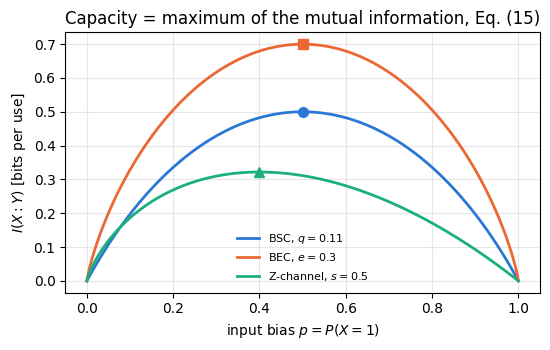

In [8]:
# ==============================================================================
# Eqs. (15)-(17): capacity as a maximum over the input distribution
# ==============================================================================
pgrid = np.linspace(0, 1, 20001)
channels = [("BSC, $q=0.11$", W_bsc(0.11), 1 - h2(0.11), 0.5),
            ("BEC, $e=0.3$", W_bec(0.3), 0.7, 0.5),
            ("Z-channel, $s=0.5$", W_z(0.5), None, 1 / (0.5 * (1 + 2 ** (h2(0.5) / 0.5))))]
fig, ax = plt.subplots(figsize=(5.6, 3.6))
for i, (name, W, C_exact, p_star) in enumerate(channels):
    I_scan = np.array([mutual_info([1 - p, p], W) for p in pgrid[::20]])    # general formula on a coarse grid
    pfine = pgrid
    I_fine = (I_bsc(pfine, 0.11) if i == 0 else I_bec(pfine, 0.3) if i == 1 else I_z(pfine, 0.5))
    assert np.max(np.abs(I_scan - I_fine[::20])) < TOL
    j = int(np.argmax(I_fine))
    C_num, p_num = I_fine[j], pfine[j]
    if C_exact is None:                                                       # Z-channel: Eq. (17), then Eq. (14)
        C_exact = I_z(p_star, 0.5)
    print(f"{name.replace('$', ''):20s}: max over p of I = {C_num:.5f} at p = {p_num:.4f};"
          f"  closed form C = {C_exact:.5f} at p* = {p_star:.4f}")
    assert abs(C_num - C_exact) < 1e-7 and abs(p_num - p_star) < 1e-3
    ax.plot(pfine, I_fine, color=PALETTE[i], lw=2, label=name)
    ax.plot(p_num, C_num, MARKERS[i], color=PALETTE[i], ms=7)
assert abs(1 / (0.5 * (1 + 2 ** (h2(0.5) / 0.5))) - 0.4) < TOL and abs(I_z(0.4, 0.5) - (h2(0.2) - 0.4)) < TOL

# wrong control: the uniform input does not reach the capacity of the asymmetric Z-channel
C_z = I_z(0.4, 0.5)
print(f"Z-channel with the uniform input: I = {I_z(0.5, 0.5):.5f} < C = {C_z:.5f}")
assert I_z(0.5, 0.5) < C_z - 0.01
ax.set_xlabel("input bias $p=P(X=1)$"); ax.set_ylabel("$I(X:Y)$ [bits per use]")
ax.set_title("Capacity = maximum of the mutual information, Eq. (15)")
ax.legend(fontsize=8); plt.tight_layout(); plt.show()

The scan finds the maxima where Eqs. (16) and (17) put them: at $p=1/2$ for the two symmetric channels, with
$C=0.500$ and $0.700$, and at $p=0.400$ for the Z-channel, with $C=0.322$ bits. The uniform input gives the Z-channel
only $0.311$ bits, so the maximum in Eq. (15) matters as soon as the channel treats its inputs differently.

### 5.3 The noisy-channel coding theorem

Capacity would be a mere number if it did not have an operational meaning. Suppose Alice wants to send one of $2^k$
messages, $k$ bits, and is allowed $n$ uses of the channel; the **rate** of her code is $R=k/n$ bits per channel use.
Bob decodes the $n$ received symbols to a guess $\hat m$, and the code fails with probability
$P_{\rm err}=P(\hat m\neq m)$. Shannon's **noisy-channel coding theorem** (Shannon 1948, Theorem 11), in the form used
in textbooks today (Cover and Thomas 2006), states:

* for every rate $R<C$ there are codes whose error probability goes to zero as the block length $n$ grows;
* for every rate $R>C$ the error probability of every code stays bounded away from zero.

Capacity is therefore the largest rate of *reliable* communication. Noise does not force the rate to zero as the
required reliability grows; it only forces it below $C$. A counting argument shows where $C$
comes from. When Alice sends a long codeword of $n$ symbols, Bob receives one of about $2^{nH(Y\vert X)}$ typical
noisy versions of it (the typical strings of Eq. (7), now for the noise), and all received strings together form a
set of about $2^{nH(Y)}$ typical strings. The codewords can be told apart only if their clouds of noisy versions do
not overlap, which allows at most

$$\frac{2^{nH(Y)}}{2^{nH(Y\vert X)}}=2^{n\,I(X:Y)} \tag{18}$$

distinguishable messages, a rate of at most $I(X{:}Y)\leq C$ bits per use.

The same counting shows why every rate below $C$ is achievable. Shannon drew the codebook *at random*: each of the
$2^{nR}$ codewords is a string of $n$ fair coin tosses, and Bob decodes to the codeword closest to the received string
in **Hamming distance**, the number of positions in which two strings differ. On the BSC the noise flips about $nq$ of
the $n$ bits, and there are about $2^{n\,h(q)}$ such flip patterns (Eq. (7) for the noise), so each sent codeword
spreads into a cloud of about $2^{n\,h(q)}$ typical outputs. A wrong codeword is a uniformly random string, which lands
in the cloud around the received string with probability about $2^{n\,h(q)}/2^n$. With $2^{nR}$ codewords, the
probability that any wrong one does is at most about

$$2^{nR}\,2^{-n(1-h(q))}=2^{-n(C-R)},$$

which vanishes as $n$ grows whenever $R<C$ (Shannon 1948; Cover and Thomas 2006, Ch. 7). Above capacity the expected
number of wrong codewords inside the cloud grows like $2^{n(R-C)}$, and decoding fails more and more often. The next
cell tests this on the BSC with $q=0.11$, where $C=0.500$. For every block length it draws $10^4$ independent
codebooks, sends the first codeword and decodes by minimum distance, with ties broken at random. One rate lies below
capacity, $R=1/4$ with $n\leq24$ (at most $64$ codewords), the other above, $R=2/3$ with $n\leq12$ (at most $256$).

R = 0.250 (below C = 0.500): block error 0.104 (n=4), 0.095 (n=8), 0.075 (n=12), 0.060 (n=16), 0.045 (n=20), 0.036 (n=24)


R = 0.667 (above C = 0.500): block error 0.325 (n=3), 0.396 (n=6), 0.445 (n=9), 0.498 (n=12)


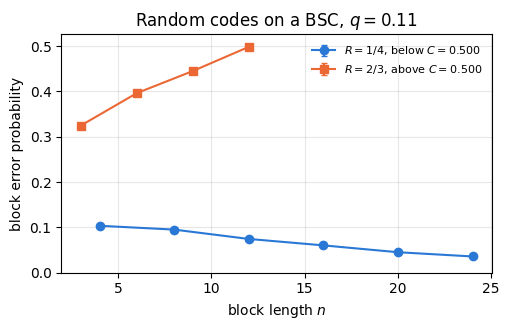

In [9]:
# ==============================================================================
# Random codes on a BSC: block error against block length below and above capacity
# ==============================================================================
Q_RC, NBOOK, NMAX, MMAX = 0.11, 10_000, 24, 256      # codebooks per point; largest block length and codebook
C_RC = 1 - h2(Q_RC)


def random_code_error(key, n, k, q):
    """One random codebook of 2^k codewords of length n; send codeword 0 through a BSC(q), decode by minimum distance.

    Codewords are stored as n-bit integers, so the Hamming distance is the number of ones in their bitwise XOR.
    Arrays have the fixed sizes MMAX and NMAX, with unused codewords and bit positions masked, so that one compiled
    function serves every (n, k). Returns the error probability of a random tie-break: 1 if a wrong codeword is
    strictly closer, t/(t+1) if t wrong codewords tie with the sent one, 0 otherwise.
    """
    k1, k2 = jax.random.split(key)
    pos = jnp.arange(NMAX, dtype=jnp.uint32)
    book = jax.random.bits(k1, (MMAX,), jnp.uint32) & ((jnp.uint32(1) << n) - 1)
    flips = jax.random.bernoulli(k2, q, (NMAX,)) & (pos < n)
    received = book[0] ^ jnp.sum(jnp.where(flips, jnp.uint32(1) << pos, 0)).astype(jnp.uint32)
    dist = jax.lax.population_count(book ^ received)
    wrong = (jnp.arange(MMAX) >= 1) & (jnp.arange(MMAX) < 2**k)
    ties = jnp.sum(wrong & (dist == dist[0]))
    return jnp.where(jnp.any(wrong & (dist < dist[0])), 1.0, ties / (ties + 1.0))


random_code_batch = jax.jit(jax.vmap(random_code_error, in_axes=(0, None, None, None)))
rc_rows = {}
for R, ns, base in ((1 / 4, (4, 8, 12, 16, 20, 24), 400), (2 / 3, (3, 6, 9, 12), 500)):
    rc_rows[R] = []
    for n in ns:
        keys = jax.random.split(key_for(base + n), NBOOK)                     # one key per codebook and noise draw
        err = np.asarray(random_code_batch(keys, n, round(n * R), Q_RC))
        rc_rows[R].append((n, err.mean(), err.std() / np.sqrt(NBOOK)))
    print(f"R = {R:.3f} ({'below' if R < C_RC else 'above'} C = {C_RC:.3f}): block error "
          + ", ".join(f"{p:.3f} (n={n})" for n, p, _ in rc_rows[R]))
lo, hi = rc_rows[1 / 4], rc_rows[2 / 3]
assert all(a[1] > b[1] for a, b in zip(lo, lo[1:]))                          # R < C: falls at every step in n
assert lo[0][1] - lo[-1][1] > 5 * np.hypot(lo[0][2], lo[-1][2])
assert hi[-1][1] - hi[0][1] > 5 * np.hypot(hi[0][2], hi[-1][2])               # R > C: rises

fig, ax = plt.subplots(figsize=(5.2, 3.4))
for i, (R, rows) in enumerate(rc_rows.items()):
    ax.errorbar([r[0] for r in rows], [r[1] for r in rows], yerr=[r[2] for r in rows], fmt=MARKERS[i] + "-",
                color=PALETTE[i], capsize=2, label=f"$R={'1/4' if i == 0 else '2/3'}$, "
                + ("below" if R < C_RC else "above") + f" $C={C_RC:.3f}$")
ax.set_xlabel("block length $n$"); ax.set_ylabel("block error probability")
ax.set_title(f"Random codes on a BSC, $q={Q_RC}$"); ax.set_ylim(0, None)
ax.legend(fontsize=8); plt.tight_layout(); plt.show()

At rate $1/4$, half the capacity, the block error of codebooks drawn blindly falls at every step, from $0.104$ at
$n=4$ to $0.036$ at $n=24$. The fall is slow at these short lengths, because the exponent $n(C-R)$ grows by only
$1/4$ per added bit. At rate $2/3$, above capacity, the block error rises instead, from $0.325$ at $n=3$ to $0.498$ at
$n=12$. The bars, one standard error over the $10^4$ codebooks, are smaller than the markers.

Random codes come close to the capacity, but they cannot be decoded efficiently: minimum-distance decoding compares
the received string with all $2^{nR}$ codewords, a number that grows exponentially with $n$. The search for codes that
approach the capacity *and* can be decoded fast took decades. Two families that do are low-density parity-check codes
(Richardson, Shokrollahi and Urbanke 2001) and polar codes, which provably reach the capacity of channels such as the
BSC (Arıkan 2009); the 5G mobile standard encodes its data with the first and its control information with the second
(3GPP TS 38.212). Section 6 studies two simple codes and shows how far from $C$ they stay.

## 6. Error correction

### 6.1 The repetition code

The simplest code repeats every bit $n$ times, $0\to00\cdots0$ and $1\to11\cdots1$, and decodes by **majority
vote**. For odd $n$ the vote is wrong when more than half of the $n$ copies are flipped, which on a BSC happens with
the binomial probability

$$P_{\rm err}(n)=\sum_{j=(n+1)/2}^{n}\binom nj\,q^j(1-q)^{n-j}. \tag{19}$$

For $q=0.1$ and $n=3$ this is $3q^2(1-q)+q^3=0.028$, a reduction of the error rate by a factor of $3.6$, paid for by
a rate $R=1/3$. The error falls exponentially with $n$, but the rate $1/n$ falls to zero with it, so the repetition code
buys reliability only by giving up the rate. An even number of copies does not help. A tie, which happens with
probability $\binom{n}{n/2}q^{n/2}(1-q)^{n/2}$, has to be broken by a coin toss; for $n=2$ the error probability is
$q^2+\tfrac12\cdot2q(1-q)=q$, exactly the uncoded value, so the second copy is wasted.

The next cell simulates the repetition code at $q=0.1$ for $n=1,\dots,15$, compares the measured error rate with
Eq. (19), and runs the even-$n$ wrong control.

In [10]:
# ==============================================================================
# Eq. (19): the repetition code with majority vote on a BSC
# ==============================================================================
Q_REP, NMSG = 0.1, 400_000


def p_err_repetition(n, q):
    """Eq. (19) for odd n; for even n, ties are broken by a fair coin."""
    tail = sum(comb(n, j) * q**j * (1 - q)**(n - j) for j in range(n // 2 + 1, n + 1))
    tie = 0.5 * comb(n, n // 2) * q**(n // 2) * (1 - q)**(n // 2) if n % 2 == 0 else 0.0
    return tail + tie


def simulate_repetition(key, n, q, nmsg):
    """Each message bit is sent n times through a BSC(q); majority vote, ties by a fair coin. Returns error rate."""
    k1, k2, k3 = jax.random.split(key, 3)
    msg = jax.random.bernoulli(k1, 0.5, (nmsg,))
    flips = jax.random.bernoulli(k2, q, (nmsg, n))
    received = jnp.logical_xor(msg[:, None], flips)
    ones = received.sum(1)
    tie_coin = jax.random.bernoulli(k3, 0.5, (nmsg,))
    decoded = jnp.where(2 * ones > n, True, jnp.where(2 * ones < n, False, tie_coin))
    return float(jnp.mean(decoded != msg))


assert abs(p_err_repetition(3, 0.1) - (3 * 0.01 * 0.9 + 0.001)) < TOL
rep_rows = []
print(" n |  rate  | P_err simulated | Eq. (19)  ")
for n in range(1, 16):
    pe_sim = simulate_repetition(key_for(100 + n), n, Q_REP, NMSG)
    pe_th = p_err_repetition(n, Q_REP)
    rep_rows.append((n, 1 / n, pe_sim, pe_th))
    print(f"{n:2d} | {1 / n:.4f} | {pe_sim:.2e}        | {pe_th:.2e}")
    assert abs(pe_sim - pe_th) < 5 * binom_se(pe_th, NMSG) + 5 / NMSG
# wrong control: two copies with a fair tie-break are no better than one
assert abs(p_err_repetition(2, Q_REP) - Q_REP) < TOL
assert abs(p_err_repetition(4, Q_REP) - p_err_repetition(3, Q_REP)) < TOL     # and n = 4 equals n = 3

 n |  rate  | P_err simulated | Eq. (19)  


 1 | 1.0000 | 1.00e-01        | 1.00e-01


 2 | 0.5000 | 9.98e-02        | 1.00e-01


 3 | 0.3333 | 2.82e-02        | 2.80e-02


 4 | 0.2500 | 2.77e-02        | 2.80e-02


...

11 | 0.0909 | 3.30e-04        | 2.96e-04


12 | 0.0833 | 2.85e-04        | 2.96e-04


13 | 0.0769 | 1.42e-04        | 9.93e-05


14 | 0.0714 | 1.07e-04        | 9.93e-05


15 | 0.0667 | 4.25e-05        | 3.36e-05


The simulated error rates follow Eq. (19) over more than three orders of magnitude, from $0.1$ at $n=1$ to
$3.4\times10^{-5}$ at $n=15$ (rate $0.067$), where only $17$ of the $4\times10^5$ messages fail. The wrong control behaves as
predicted: an even number of copies adds a tie that is broken by a coin, and $P_{\rm err}(2)=P_{\rm err}(1)$,
$P_{\rm err}(4)=P_{\rm err}(3)$ exactly. The capacity of this channel is $C=1-h(0.1)=0.531$; the repetition code
reaches small error rates only at rates far below it.

### 6.2 The Hamming(7,4) code

Hamming (1950) found a far better trade-off for a single error per block. His code sends $4$ message bits in a block
of $7$, at rate $R=4/7\approx0.571$, and corrects any single error in the block. Number the positions $1,\dots,7$.
Positions $1$, $2$ and $4$ (the powers of two) carry parity bits and the others, $3,5,6,7$, the message. Each parity
bit is chosen so that a group of positions has an even number of ones:

* check 1 covers positions $1,3,5,7$, the positions whose binary number has a $1$ in the last digit;
* check 2 covers positions $2,3,6,7$, a $1$ in the middle digit;
* check 3 covers positions $4,5,6,7$, a $1$ in the first digit.

In matrix form the three checks are the rows of the **parity-check matrix** $\mathsf H$, whose column $j$ is the
binary number $j$ written top to bottom from the lowest digit:

$$\mathsf H=\begin{pmatrix}1&0&1&0&1&0&1\\0&1&1&0&0&1&1\\0&0&0&1&1&1&1\end{pmatrix},\qquad
\mathsf H\,\mathbf c=\mathbf 0\pmod2\ \text{for every codeword }\mathbf c. \tag{20}$$

If the channel adds an error pattern $\mathbf e$ (a $1$ at every flipped position), Bob receives
$\mathbf y=\mathbf c\oplus\mathbf e$, where $\oplus$ is addition modulo 2 position by position, and computes the
**syndrome**

$$\mathbf s=\mathsf H\,\mathbf y=\mathsf H\,\mathbf c\oplus\mathsf H\,\mathbf e=\mathsf H\,\mathbf e\pmod2. \tag{21}$$

The syndrome does not depend on the message, only on the error. A single error at position $j$ gives the $j$-th
column of $\mathsf H$, which is the binary number $j$: the syndrome *spells out the position of the error*, and Bob
flips that bit. Hamming's paper describes exactly this "checking number". Two or more errors always end on a wrong
codeword: the syndrome then points to a third position, or is zero because the errors themselves form a codeword. The
block therefore fails with the probability that more than one of its seven bits is flipped,

$$P_{\rm block}=1-(1-q)^7-7q(1-q)^6. \tag{22}$$

Any two codewords differ in at least three positions (the **minimum distance** is $3$), which is why one error can
always be undone: the corrupted word is still closer to the codeword it came from than to any other.

The next cell builds the 16 codewords, checks Eq. (20) and the minimum distance, verifies that every single error is
located by its syndrome, and simulates the code on a BSC with $q=0.05$ and $q=0.1$.

In [11]:
# ==============================================================================
# Eqs. (20)-(22): Hamming(7,4) with syndrome decoding
# ==============================================================================
Hmat = np.array([[(j >> b) & 1 for j in range(1, 8)] for b in range(3)], dtype=np.uint8)   # column j = binary j
DATA_POS, CHECK_POS = [2, 4, 5, 6], [0, 1, 3]            # 0-based indices of positions 3,5,6,7 and 1,2,4


def hamming_encode(d):
    """Message bits d (..., 4) -> codewords (..., 7): data at positions 3,5,6,7, even parity over each check group."""
    c = np.zeros(d.shape[:-1] + (7,), dtype=np.uint8)
    c[..., DATA_POS] = d
    for b, pos in enumerate(CHECK_POS):                   # check b covers the positions whose bit b is 1
        c[..., pos] = (c @ Hmat[b]) % 2                   # the check position itself is still 0 here
    return c


def hamming_decode(y):
    """Received words (..., 7) -> message bits (..., 4): syndrome, Eq. (21), read as a position, flip it."""
    s = (y @ Hmat.T) % 2                                  # (..., 3), lowest digit first
    pos = s @ np.array([1, 2, 4])                         # 0 = no error, j = error at position j
    y = y.copy()
    idx = np.nonzero(pos)[0] if y.ndim == 2 else ([0] if pos else [])
    if y.ndim == 2:
        y[idx, pos[idx] - 1] ^= 1
    elif pos:
        y[pos - 1] ^= 1
    return y[..., DATA_POS]


messages = np.array(list(itertools.product([0, 1], repeat=4)), dtype=np.uint8)
codewords = hamming_encode(messages)
assert np.all((codewords @ Hmat.T) % 2 == 0)                                   # Eq. (20)
dist = (codewords[:, None, :] != codewords[None, :, :]).sum(-1)
d_min = dist[~np.eye(16, dtype=bool)].min()
print(f"16 codewords, minimum distance {d_min}; example: message 1011 -> codeword {''.join(map(str, codewords[11]))}")
assert d_min == 3
for c, m in zip(codewords, messages):                                         # every single error is corrected
    for j in range(7):
        e = np.zeros(7, dtype=np.uint8); e[j] = 1
        assert ((Hmat @ (c ^ e)) % 2) @ np.array([1, 2, 4]) == j + 1          # syndrome = position, Eq. (21)
        assert np.array_equal(hamming_decode(c ^ e), m)
# wrong control: two errors are mis-corrected (the syndrome points to a third position)
c, e2 = codewords[11], np.array([1, 1, 0, 0, 0, 0, 0], dtype=np.uint8)
assert not np.array_equal(hamming_decode(c ^ e2), messages[11])

NBLK = 200_000
ham_rows = []
for i, q in enumerate((0.05, 0.1)):
    k1, k2 = jax.random.split(key_for(200 + i))
    m = np.asarray(jax.random.bernoulli(k1, 0.5, (NBLK, 4)), dtype=np.uint8)
    flips = np.asarray(jax.random.bernoulli(k2, q, (NBLK, 7)), dtype=np.uint8)
    m_hat = hamming_decode(hamming_encode(m) ^ flips)
    block_err = np.mean(np.any(m_hat != m, axis=1))
    bit_err = np.mean(m_hat != m)
    P_block = 1 - (1 - q)**7 - 7 * q * (1 - q)**6                              # Eq. (22)
    ham_rows.append((q, bit_err, block_err, P_block))
    print(f"q = {q}: block error {block_err:.4f} (Eq. 22: {P_block:.4f}), message-bit error {bit_err:.4f},"
          f" repetition n=3 at rate 1/3: {p_err_repetition(3, q):.4f}, capacity {1 - h2(q):.3f}")
    assert abs(block_err - P_block) < 5 * binom_se(P_block, NBLK)

16 codewords, minimum distance 3; example: message 1011 -> codeword 0110011


q = 0.05: block error 0.0443 (Eq. 22: 0.0444), message-bit error 0.0195, repetition n=3 at rate 1/3: 0.0073, capacity 0.714
q = 0.1: block error 0.1504 (Eq. 22: 0.1497), message-bit error 0.0669, repetition n=3 at rate 1/3: 0.0280, capacity 0.531


All $16\times7$ single errors are located by their syndromes, and the two-error wrong control decodes to a wrong
message. On the simulated channel the block error rate agrees with Eq. (22): $0.044$ at $q=0.05$ and $0.150$ at
$q=0.1$. Per message bit, the error falls from $q=0.05$ to $0.020$ at rate $4/7$, while the repetition code
needs rate $1/3$ to reach $0.007$. The plot places both codes in the plane of rate and error and compares them with
the capacity $C=1-h(0.1)=0.531$ of the channel with $q=0.1$. The bars on the simulated repetition points are one
binomial standard error, $\sigma=\sqrt{p(1-p)/M}$ for an error frequency $p$ observed in $M=4\times10^5$ messages;
they become visible only for the longest codes, where few messages fail.

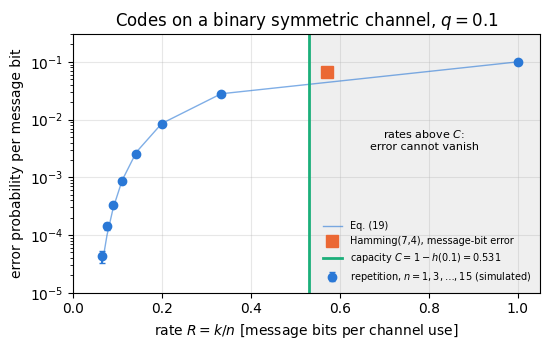

In [12]:
# ==============================================================================
# The rate-error plane at q = 0.1: repetition codes, Hamming(7,4) and the capacity
# ==============================================================================
fig, ax = plt.subplots(figsize=(5.6, 3.6))
odd = [r for r in rep_rows if r[0] % 2 == 1]
assert all(r[2] > 0 for r in odd)                    # every simulated point has failures, so it fits a log axis
ax.errorbar([r[1] for r in odd], [r[2] for r in odd], yerr=[binom_se(r[2], NMSG) for r in odd], fmt=MARKERS[0],
            color=PALETTE[0], capsize=2, label="repetition, $n=1,3,\\ldots,15$ (simulated)")
ax.set_yscale("log")
ax.semilogy([r[1] for r in odd], [r[3] for r in odd], "-", color=PALETTE[0], lw=1, alpha=0.6, label="Eq. (19)")
q01 = [r for r in ham_rows if r[0] == 0.1][0]
ax.semilogy(4 / 7, q01[1], MARKERS[1], color=PALETTE[1], ms=8, label="Hamming(7,4), message-bit error")
C01 = 1 - h2(0.1)
ax.axvline(C01, color=PALETTE[2], lw=2, label=f"capacity $C=1-h(0.1)={C01:.3f}$")
ax.axvspan(C01, 1.05, color="gray", alpha=0.12)
ax.text(0.79, 3e-3, "rates above $C$:\nerror cannot vanish", fontsize=8, ha="center")
ax.set_xlim(0, 1.05); ax.set_ylim(1e-5, 0.3)
ax.set_xlabel("rate $R=k/n$ [message bits per channel use]"); ax.set_ylabel("error probability per message bit")
ax.set_title("Codes on a binary symmetric channel, $q=0.1$")
ax.legend(fontsize=7, loc="lower right"); plt.tight_layout(); plt.show()
assert 4 / 7 > C01                                   # Hamming(7,4) runs above capacity at q = 0.1 ...
assert q01[1] > 0.02                                 # ... and its residual error is correspondingly large

At $q=0.1$ the Hamming code runs at rate $4/7=0.571$, *above* the capacity $0.531$. At this rate no code of any
length can make the error vanish, and the Hamming code lowers the error per message bit only from $0.1$ to $0.067$. At $q=0.05$ the same code runs below the
capacity $0.714$, but a block of seven bits is too short to approach the limit. The repetition codes stay far left in
the plot: every factor of ten in reliability costs them a large factor in rate. Approaching the boundary at $C$ needs
long codes with many interlocking parity checks.

### 6.3 Correcting a shared key by public parity checks

The same parity idea solves a different problem, which will be central in quantum key distribution. Alice and Bob
already hold two long strings $\mathbf a$ and $\mathbf b$ that agree except in a small fraction $Q$ of the positions,
for example because $\mathbf b$ came to Bob through a noisy channel. They can talk over a *public* channel, which
anyone may listen to, and want to make the strings identical. This is called **information reconciliation**. Sending
$\mathbf a$ itself would reveal everything, so they exchange parities instead.

The basic step is a **binary search**. Alice and Bob cut the strings into blocks of length $L$ and announce the parity
(the sum modulo 2) of each block. Where the parities differ, the block contains an odd number of errors, at least
one. They then compare the parity of the first half of that block: if it differs, an odd number of errors sits in the
first half, otherwise in the second. Halving again and again isolates one error after at most

$$\lceil\log_2L\rceil\ \text{further parities}, \tag{23}$$

and Bob flips that bit. A block with an *even* number of errors has matching parities and hides its errors, so the
procedure is repeated in several passes, each time after a public random permutation of the positions, with blocks
twice as long as in the previous pass, because fewer errors remain. This is the binary-search primitive BINARY and the shuffled-pass structure
described by Brassard and Salvail (1994); their protocol Cascade adds a backtracking step that reuses old parities and
is omitted here. The first-pass block length is set to about $0.73/Q$, so that a block holds $0.73$ errors on
average and most blocks hold none or one; this is close to the values of their benchmark ($73$,
$14$ and $7$ bits at $Q=0.01$, $0.05$ and $0.1$).

Every announced parity is at most one bit of information about the key, and a listener, later Eve, learns it too.
The minimum number of parities follows from Bob's uncertainty about Alice's string, the conditional entropy. For a
uniformly random string $\mathbf a$ and independent errors at rate $Q$ it is $H(\mathbf a\vert\mathbf b)=n\,h(Q)$,
$n$ times the noisy copy of Section 4. Shannon's Theorem 10 states that an extra channel that tells the receiver
which bits to correct must carry at least this much, and Brassard and Salvail (1994, Theorem 2) proved the same
bound for any reconciliation protocol, interactive ones included. For long strings every successful reconciliation
therefore reveals at least

$$\text{leak}\;\geq\;n\,h(Q),\qquad f\equiv\frac{\text{leak}}{n\,h(Q)}\geq1, \tag{24}$$

with the **efficiency** $f$ measuring how close a practical protocol comes to the limit. Below we count every
announced parity as one leaked bit, which can only overestimate the information. The first cell walks
through one binary search by hand; the second runs the full multi-pass procedure on keys of $2\times10^4$ bits.

In [13]:
# ==============================================================================
# Eq. (23): one binary search on a block of eight bits
# ==============================================================================
def parity(v):
    return int(np.sum(v) % 2)


def binary_search(a_blk, b_blk, verbose=False):
    """Locate one error in a block whose parities differ; returns (index, number of parities revealed)."""
    lo, hi, revealed = 0, len(a_blk), 0
    while hi - lo > 1:
        mid = (lo + hi) // 2
        pa, pb = parity(a_blk[lo:mid]), parity(b_blk[lo:mid])
        revealed += 1                                      # Alice announces the parity of a[lo:mid]
        if verbose:
            print(f"  positions {lo}..{mid - 1}: Alice {pa}, Bob {pb} -> error in "
                  f"{'this half' if pa != pb else 'the other half'}")
        lo, hi = (lo, mid) if pa != pb else (mid, hi)
    return lo, revealed


a_blk = np.array([1, 0, 1, 1, 0, 0, 1, 0], dtype=np.uint8)
b_blk = a_blk.copy(); b_blk[5] ^= 1
print("Alice:", "".join(map(str, a_blk)), "  Bob:", "".join(map(str, b_blk)),
      f"  block parities {parity(a_blk)} vs {parity(b_blk)}")
pos, rev = binary_search(a_blk, b_blk, verbose=True)
print(f"error found at position {pos} with 1 + {rev} parities revealed")
assert pos == 5 and rev == int(np.ceil(np.log2(8)))                           # Eq. (23)
for L in (8, 16, 37, 64, 100):                                                # Eq. (23) for any position and length
    for j in range(L):
        aa = np.zeros(L, dtype=np.uint8); bb = aa.copy(); bb[j] = 1
        p, r = binary_search(aa, bb)
        assert p == j and r <= int(np.ceil(np.log2(L)))
# wrong control: two errors in one block leave the parities equal and are invisible
b2 = a_blk.copy(); b2[1] ^= 1; b2[6] ^= 1
assert parity(a_blk) == parity(b2)
print("two errors in the block: parities", parity(a_blk), parity(b2), "-> undetected in this pass")

Alice: 10110010   Bob: 10110110   block parities 0 vs 1
  positions 0..3: Alice 1, Bob 1 -> error in the other half
  positions 4..5: Alice 0, Bob 1 -> error in this half
  positions 4..4: Alice 0, Bob 0 -> error in the other half
error found at position 5 with 1 + 3 parities revealed
two errors in the block: parities 0 0 -> undetected in this pass


 Q    | L  | errors before | after | leaked/n | h(Q)   | f = leak/(n h(Q))


 0.01 | 73 |           193 |     0 | 0.0957   | 0.0808 | 1.185
 0.02 | 36 |           403 |     0 | 0.1779   | 0.1414 | 1.258


 0.05 | 15 |          1000 |     0 | 0.3719   | 0.2864 | 1.299


 0.10 |  7 |          2052 |     0 | 0.6590   | 0.4690 | 1.405


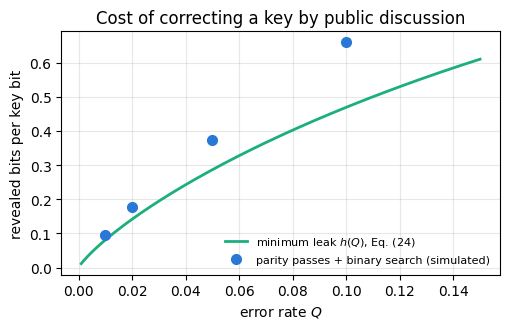

In [14]:
# ==============================================================================
# Eq. (24): multi-pass reconciliation, leaked bits against n h(Q)
# ==============================================================================
def reconcile(a, b, L, passes, perm_rng):
    """Shuffled passes of block parities + binary search (no backtracking). Returns (corrected b, parities revealed)."""
    b = b.copy(); n = len(a); leak = 0
    for p in range(passes):
        perm = np.arange(n) if p == 0 else perm_rng.permutation(n)            # public random permutation
        Lp = L * 2**p
        for start in range(0, n, Lp):
            idx = perm[start:start + Lp]
            leak += 1                                                          # block parity
            if parity(a[idx]) != parity(b[idx]):
                j, r = binary_search(a[idx], b[idx])
                leak += r
                b[idx[j]] ^= 1
    return b, leak


NKEY, PASSES = 20_000, 8
print(f" Q    | L  | errors before | after | leaked/n | h(Q)   | f = leak/(n h(Q))")
rec_rows = []
for i, Q in enumerate((0.01, 0.02, 0.05, 0.1)):
    k1, k2, k3 = jax.random.split(key_for(300 + i), 3)
    a = random_bits(k1, NKEY)
    b = a ^ random_bits(k2, NKEY, Q)
    L = max(2, int(round(0.73 / Q)))                     # first-pass blocks hold about 0.73 errors on average
    perm_rng = np.random.default_rng(int(jax.random.randint(k3, (), 0, 2**31 - 1)))   # public permutations
    b_fixed, leak = reconcile(a, b, L, PASSES, perm_rng)
    residual = int(np.sum(a != b_fixed))
    f = leak / (NKEY * h2(Q))
    rec_rows.append((Q, leak / NKEY, f, residual))
    print(f" {Q:4.2f} | {L:2d} | {int(np.sum(a != b)):13d} | {residual:5d} | {leak / NKEY:.4f}   | {h2(Q):.4f} | {f:.3f}")
    assert residual == 0                                 # the keys agree after 8 passes
    assert 1.0 < f < 1.5                                 # Eq. (24): above the limit, within 50 % of it

fig, ax = plt.subplots(figsize=(5.2, 3.4))
Qs = np.linspace(0.001, 0.15, 300)
ax.plot(Qs, h2(Qs), color=PALETTE[2], lw=2, label="minimum leak $h(Q)$, Eq. (24)")
ax.plot([r[0] for r in rec_rows], [r[1] for r in rec_rows], MARKERS[0], color=PALETTE[0], ms=7,
        label="parity passes + binary search (simulated)")
ax.set_xlabel("error rate $Q$"); ax.set_ylabel("revealed bits per key bit")
ax.set_title("Cost of correcting a key by public discussion")
ax.legend(fontsize=8); plt.tight_layout(); plt.show()

The hand-worked block shows the search: after the block parity, three further parities ($\log_28$) pin the error to
position $5$, counting from $0$ as the code does. In the full procedure eight shuffled passes removed every error from keys of $2\times10^4$ bits at all
four error rates, and the number of revealed parities was $f=1.19$ to $1.41$ times the minimum $n\,h(Q)$ of
Eq. (24), closer at low error rates. At $Q=0.1$ Alice and Bob reveal $0.66$ bits per key bit, so a listener who
hears only the parities still lacks at least $341$ bits of every thousand. Cascade, which reuses earlier parities to
find hidden pairs of errors, reaches $f\approx1.10$ to $1.16$ for $Q=0.01$ to $0.1$ in the benchmark of Brassard and
Salvail (1994), and long parity-check codes come closer still, but no protocol can go below $f=1$.

## 7. From reliable communication to secret communication

Noise costs bits twice. It lowers the rate at which a channel can carry information, from one bit per use to
$1-h(q)$, and correcting the errors on a shared string consumes about $h(Q)$ publicly announced bits per key bit.
Both costs are governed by the same binary entropy, and both will reappear when we account for a quantum key: the
error rate measured on the key sets the cost of reconciliation, and it also bounds what an eavesdropper can know.

Reliability is not secrecy. Everything in this notebook was public: the code, the parity bits and the corrected key
itself would all be visible to Eve if she tapped the line. The chapter continues with hiding the *content* of a
message from her. The answer, the one-time pad, is perfectly secure but needs a secret random key as long as
the message, shared in advance and used only once, and it moves the whole difficulty into distributing that key.
Quantum mechanics offers a way to distribute keys whose secrecy rests on physics, and the protocols of the
quantum part of the chapter combine it with the parity-check reconciliation of Section 6.3. Quantum channels themselves, maps that send
density matrices to density matrices, and their capacities appear later in this chapter.

## 8. Key takeaways

* **Entropy is average surprise and the limit of compression.** $H(X)=-\sum_xp(x)\log_2p(x)$, Eq. (2), between $0$
  and $\log_2M$. Huffman codes on blocks of six tosses compressed a coin with $p(1)=0.1$ to $0.470$ bits per toss,
  against $H=h(0.1)=0.469$, and the real string decompressed without error.
* **Conditional entropy and mutual information do the bookkeeping.** $H(X\vert Y)=H(X,Y)-H(Y)$ and
  $I(X{:}Y)=H(X)-H(X\vert Y)$, symmetric and never negative. The parity of a die carries exactly one bit about it; a
  copy with $10\,\%$ errors carries $0.531$ bits.
* **A channel is a stochastic matrix, and its capacity is the maximum mutual information.** $C=\max_PI(X{:}Y)$,
  Eq. (15). A scan over the input bias gives $C_{\rm BSC}=1-h(q)$ and $C_{\rm BEC}=1-e$ at the uniform input, and
  $C_{\rm Z}=0.322$ at $p^\star=0.4$ for the Z-channel with $s=1/2$, where the uniform input gives only $0.311$.
* **Reliable communication is possible at every rate below capacity**, by Shannon's noisy-channel coding theorem, and
  at no rate above it. A known erasure costs less than a hidden error: $C=0.700$ for $30\,\%$ erasures against $0.500$
  for $11\,\%$ flips.
* **Simple codes stay far from capacity.** Repetition codes, Eq. (19), trade rate for reliability without limit; an
  even number of copies is wasted. Hamming(7,4) corrects every single error with a syndrome that spells out its
  position, Eq. (21), at rate $4/7$, with block failures following Eq. (22).
* **Public parity checks reconcile a key at a cost of about $h(Q)$ bits per key bit.** Binary search locates one error
  with $\lceil\log_2L\rceil$ parities; eight shuffled passes removed all errors at $Q\leq0.1$ while revealing $1.19$ to
  $1.41$ times the minimum $n\,h(Q)$.

## 9. Exercises

1. ★ **Two values of the binary entropy.** Compute $h(0.05)$ and $h(1/4)$ by hand and with `h2`. What is the
   capacity of a binary symmetric channel with $q=1/4$?
2. ★ **Two dice.** Compute the entropy of the sum of two fair dice, and the mutual information between the sum and the
   first die.
3. ★ **A coarse observation.** $X$ is a fair die and $Y=1$ if $X\geq5$, otherwise $Y=0$. Compute $H(Y)$,
   $H(X\vert Y)$ and $I(X{:}Y)$.
4. ★★ **Two noisy links in series.** A bit passes through a BSC with $q_1$ and then through a second, independent BSC
   with $q_2$. Show that the combination is a BSC with $q=q_1(1-q_2)+q_2(1-q_1)$. Compute its capacity for
   $q_1=q_2=0.1$ and compare with the capacity of one link. Check by simulation.
5. ★★ **Five copies.** Evaluate Eq. (19) for $n=5$ and $q=0.1$ by hand and compare with the simulation of
   Section 6.1.
6. ★★ **A longer Hamming code.** The same construction with $r=4$ checks gives the Hamming(15,11) code: $\mathsf H$ has
   the binary numbers $1,\dots,15$ as columns. Implement it, verify that it corrects every single error, and compute
   its rate and its block error probability at $q=0.01$, analogous to Eq. (22).
7. ★★ **A Z-channel and a three-symbol channel.** For $s=0.1$ compute $p^\star$ from Eq. (17) and the capacity from
   Eq. (14), and check both with the scan of Section 5.2. A ternary symmetric channel has inputs and outputs $0,1,2$;
   each symbol arrives correctly with probability $1-\varepsilon$ and as each of the two other symbols with probability
   $\varepsilon/2$. Show that $H(Y\vert X)$ does not depend on the input distribution and that the uniform input
   maximises $H(Y)$, so that $C=\log_23-h(\varepsilon)-\varepsilon$. Evaluate it for $\varepsilon=0.1$ and check it
   with `mutual_info` on a grid of input distributions $(P_0,P_1,1-P_0-P_1)$.
8. ★★★ **One known error.** A block of $L=2^m$ bits is known to contain exactly one error, at a uniformly random
   position. Show that $m$ parities
   locate it and that no strategy can do with fewer on average. Compare the cost per bit, $(m+1)/L$ including the
   block parity, with $h(1/L)$ for $L=8$, $64$ and $1024$, and explain why it can lie *below* $h(1/L)$ without
   contradicting Eq. (24).

*Check values.* 1: $h(0.05)=0.286$, $h(1/4)=0.811$, $C=0.189$ bits per use. 2: $H(\text{sum})=3.274$ bits;
$I=H(\text{sum})-H(\text{second die})=3.274-2.585=0.689$ bits. 3: $H(Y)=h(1/3)=0.918$, $H(X\vert Y)=\log_26-0.918=1.667$,
$I=0.918$ bits. 4: $q=0.18$, $C=1-h(0.18)=0.320$ against $0.531$ for one link. 5: $P_{\rm err}=0.00856$. 6: rate
$11/15=0.733$, $P_{\rm block}=1-0.99^{15}-15\cdot0.01\cdot0.99^{14}=0.0096$. 7: $p^\star=0.456$, $C=0.763$ bits;
ternary channel $C=\log_23-h(0.1)-0.1=1.016$ bits.
8: $(m+1)/L=0.500$, $0.109$, $0.0107$ against $h(1/L)=0.544$, $0.116$, $0.0112$; knowing that there is exactly one
error leaves only $\log_2L$ bits of uncertainty about the error pattern, less than the $L\,h(1/L)$ of independent
errors at rate $1/L$, which is what Eq. (24) assumes.

## References

* C. E. Shannon, *A mathematical theory of communication*, Bell Syst. Tech. J. **27**, 379 and 623 (1948),
  doi:10.1002/j.1538-7305.1948.tb01338.x and doi:10.1002/j.1538-7305.1948.tb00917.x — entropy as the measure of
  information, typical sequences (Theorem 3), the source coding theorem (Theorem 9), the equivocation and the correction channel (Theorem 10), the
  capacity $C=\max\,[H(x)-H_y(x)]$ and the noisy-channel coding theorem (Theorem 11), and the example of $1000$ bits
  per second with $1\,\%$ errors carrying $919$ bits per second.
* D. A. Huffman, *A method for the construction of minimum-redundancy codes*, Proc. IRE **40**, 1098 (1952),
  doi:10.1109/JRPROC.1952.273898 — the optimal prefix code of Section 3.4.
* R. W. Hamming, *Error detecting and error correcting codes*, Bell Syst. Tech. J. **29**, 147 (1950),
  doi:10.1002/j.1538-7305.1950.tb00463.x — single-error-correcting codes with check positions $1,2,4,\dots$ whose
  "checking number" gives the position of the error; the seven-position code with four information positions.
* G. Brassard and L. Salvail, *Secret-key reconciliation by public discussion*, in *Advances in Cryptology —
  EUROCRYPT '93*, Lecture Notes in Computer Science **765**, 410 (Springer, 1994), doi:10.1007/3-540-48285-7\_35 —
  reconciliation over a binary symmetric channel, the lower bound $n\,h(p)$ on the leaked information (Theorem 2), the binary-search primitive
  BINARY, and the protocol Cascade with its first-pass block length and its benchmark of the leaked information.
* T. Richardson, A. Shokrollahi and R. Urbanke, *Design of capacity-approaching irregular low-density parity-check
  codes*, IEEE Trans. Inf. Theory **47**, 619 (2001), doi:10.1109/18.910578 — low-density parity-check codes that
  approach the capacity.
* E. Arıkan, *Channel polarization: a method for constructing capacity-achieving codes for symmetric binary-input
  memoryless channels*, IEEE Trans. Inf. Theory **55**, 3051 (2009), doi:10.1109/TIT.2009.2021379 — polar codes, which
  reach the symmetric capacity with encoding and decoding in $O(n\log n)$ operations.
* 3GPP TS 38.212, *NR; Multiplexing and channel coding* (3rd Generation Partnership Project, Release 15 onward),
  clauses 7.2.4 and 7.3.3 — the 5G standard: low-density parity-check coding of the downlink shared (data) channel and
  polar coding of the downlink control information.
* T. M. Cover and J. A. Thomas, *Elements of Information Theory*, 2nd ed. (Wiley, Hoboken, 2006),
  doi:10.1002/047174882X — textbook treatment of entropy, mutual information, data compression and channel capacity,
  including the binary symmetric and erasure channels and the modern statement of the noisy-channel coding theorem.

---
Marcin Płodzień, PhD

**Citation:** M. Płodzień, *Quantum Many-Body Simulation: from a single spin to quantum machine learning* (2026), https://marcinplodzien.github.io/quantum-many-body-simulation/